In [9]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src')
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')
# Laptop
sys.path.append('/home/rens/projects/mp_dir/masterproject/src/')

from plotting_functions import set_styles
set_styles()

In [7]:
dpath = '../../../data/'
fpath = '../../../figures/IDA/'

# Experiment with either querying in Gaia archive, then parsing votables such as this
# Or querying directly through astroquery.gaia
# Nevertheless, full Hipp. data ~50MB. Not too bad
table_xm = fits.open(dpath+'GDR3-H-PreXM_expanded.fits')[1].data
table_noxm = fits.open(dpath+'GDR3-H-No_PreXM_expanded.fits')[1].data

## Planned for this Notebook
- Play around with the possibilities of votables and astroquery
- See if other Python packages can help with statistical analysis of Hipparcos data
    - e.g. let some kind of ML/SciPy function do a huge covariance analysis or something like that. Works better than just doing everything by eye
- Make new figures for IDA

## Figures
### Star Locations

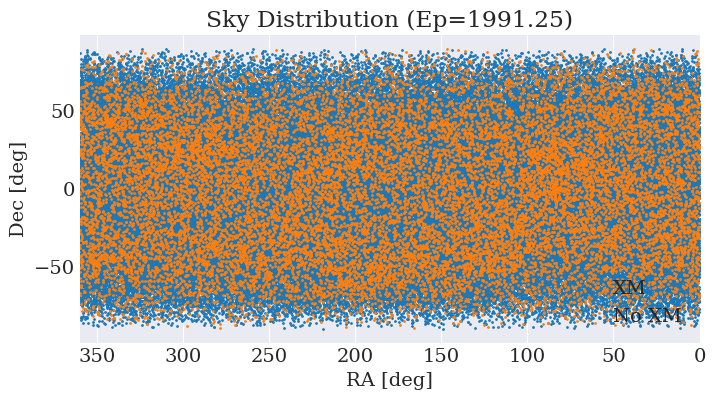

In [10]:
# RA vs. Dec
ra_xm = table_xm['ra']
de_xm = table_xm['dec']
ra_noxm = table_noxm['ra']
de_noxm = table_noxm['dec']

fig, ax = plt.subplots(1,1,figsize=(8,4))
ax.scatter(ra_xm, de_xm, s=1, label='XM')
ax.scatter(ra_noxm, de_noxm, s=1, label='No XM')

ax.set_xlabel("RA [deg]")
ax.set_ylabel("Dec [deg]")
ax.set_title("Sky Distribution (Ep=1991.25)")
ax.set_xlim(0, 360)
ax.invert_xaxis()

plt.legend(loc='lower right')
plt.savefig(fpath+'ida_skydist', bbox_inches='tight', transparent=True)
plt.show()

/tmp/ipykernel_62920/1437953081.py:8: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(plx_xm), density=True, log=True, histtype='step', lw=2, label='XM', bins=bin_edges)
/tmp/ipykernel_62920/1437953081.py:8: RuntimeWarning: invalid value encountered in log10
  ax.hist(np.log10(plx_xm), density=True, log=True, histtype='step', lw=2, label='XM', bins=bin_edges)
/tmp/ipykernel_62920/1437953081.py:9: RuntimeWarning: divide by zero encountered in log10
  ax.hist(np.log10(plx_noxm), density=True, log=True, histtype='step', lw=2, label='No XM', bins=bin_edges)
/tmp/ipykernel_62920/1437953081.py:9: RuntimeWarning: invalid value encountered in log10
  ax.hist(np.log10(plx_noxm), density=True, log=True, histtype='step', lw=2, label='No XM', bins=bin_edges)


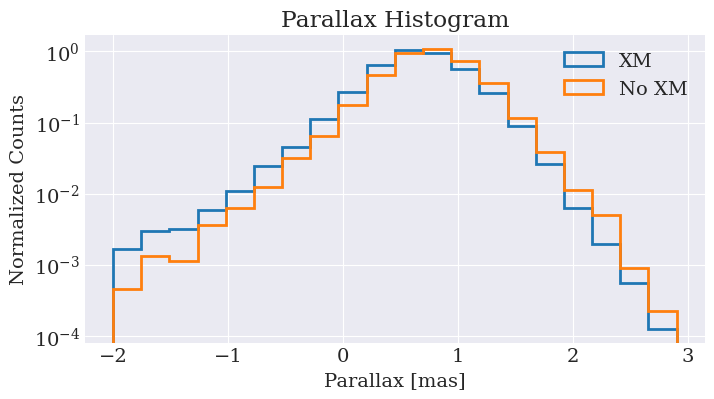

In [43]:
# Parallax
plx_xm = table_xm['plx']
plx_noxm = table_noxm['plx']

bin_edges = np.linspace(np.log10(np.min(plx_xm[plx_xm>0])), np.log10(np.max(plx_xm)), 21)

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(plx_xm), density=True, log=True, histtype='step', lw=2, label='XM', bins=bin_edges)
ax.hist(np.log10(plx_noxm), density=True, log=True, histtype='step', lw=2, label='No XM', bins=bin_edges)

ax.set_xlabel("Parallax [mas]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Parallax Histogram")

plt.legend()
plt.savefig(fpath+'ida_plx', bbox_inches='tight', transparent=True)
plt.show()

### Proper Motions

In [26]:
pmra_xm = table_xm['pm_ra']
pmde_xm = table_xm['pm_de']
epmra_xm = table_xm['e_pm_ra']
epmde_xm = table_xm['e_pm_de']

pmra_noxm = table_noxm['pm_ra']
pmde_noxm = table_noxm['pm_de']
epmra_noxm = table_noxm['e_pm_ra']
epmde_noxm = table_noxm['e_pm_de']

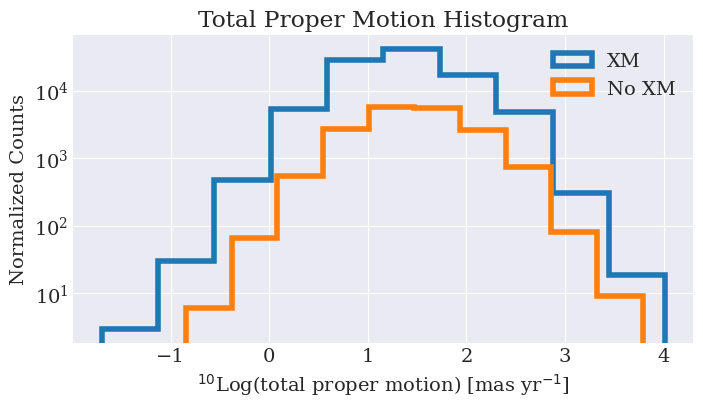

In [36]:
pm_xm = np.sqrt((pmra_xm**2) + (pmde_xm**2))
pm_noxm = np.sqrt((pmra_noxm**2) + (pmde_noxm**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(pm_xm), log=True, histtype='step', lw=4, label='XM')
ax.hist(np.log10(pm_noxm), log=True, histtype='step', lw=4, label='No XM')

ax.set_xlabel(r"$^{10}$Log(total proper motion) [mas yr$^{-1}$]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Total Proper Motion Histogram")

plt.legend()
plt.savefig(fpath+'total_pm', bbox_inches='tight', transparent=True)
plt.show()

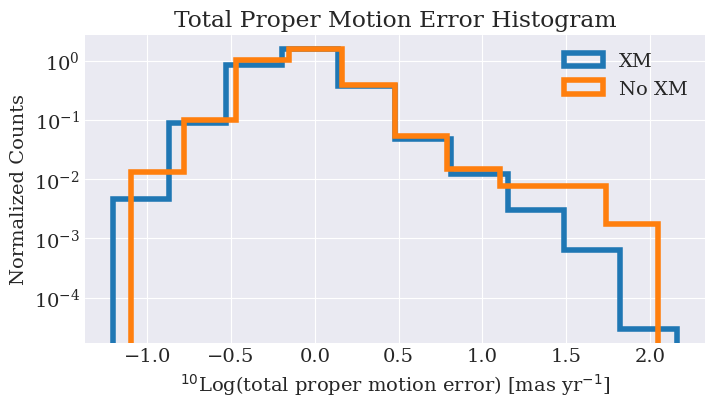

In [28]:
epm_xm = np.sqrt(((pmra_xm * epmra_xm)**2) + ((pmde_xm*epmde_xm)**2))/np.sqrt((pmra_xm**2) + (pmde_xm**2))
epm_noxm = np.sqrt(((pmra_noxm * epmra_noxm)**2) + ((pmde_noxm*epmde_noxm)**2))/np.sqrt((pmra_noxm**2) + (pmde_noxm**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(epm_xm), density=True, log=True, histtype='step', lw=4, label='XM')
ax.hist(np.log10(epm_noxm), density=True, log=True, histtype='step', lw=4, label='No XM')

ax.set_xlabel(r"$^{10}$Log(total proper motion error) [mas yr$^{-1}$]")
ax.set_ylabel("Normalized Counts")
ax.set_title("Total Proper Motion Error Histogram")

plt.legend()
plt.savefig(fpath+'e_total_pm', bbox_inches='tight', transparent=True)
plt.show()

### Magnitudes & Colours

In [29]:
hp_xm = table_xm["hp_mag"]
b_xm = table_xm["btmag"]
v_xm = table_xm["vtmag"]
bv_xm = table_xm["b_v"]
vi_xm = table_xm["v_i"]

hp_noxm = table_noxm["hp_mag"]
b_noxm = table_noxm["btmag"]
v_noxm = table_noxm["vtmag"]
bv_noxm = table_noxm["b_v"]
vi_noxm = table_noxm["v_i"]

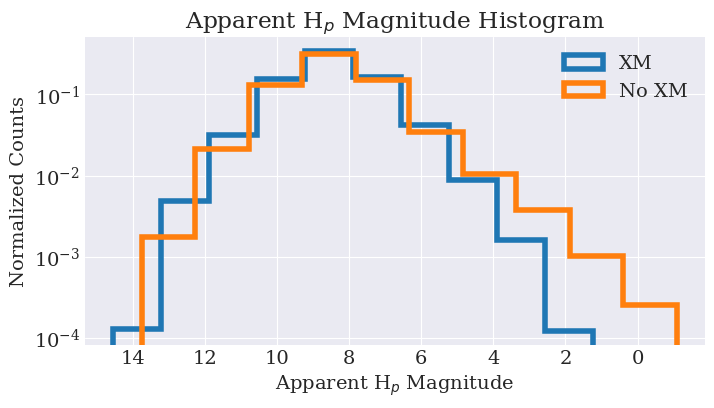

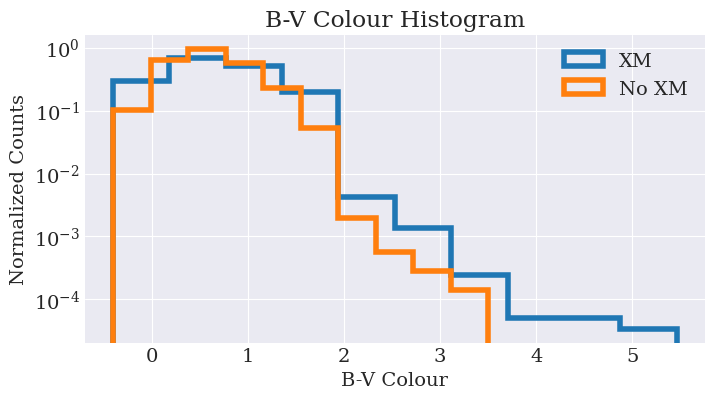

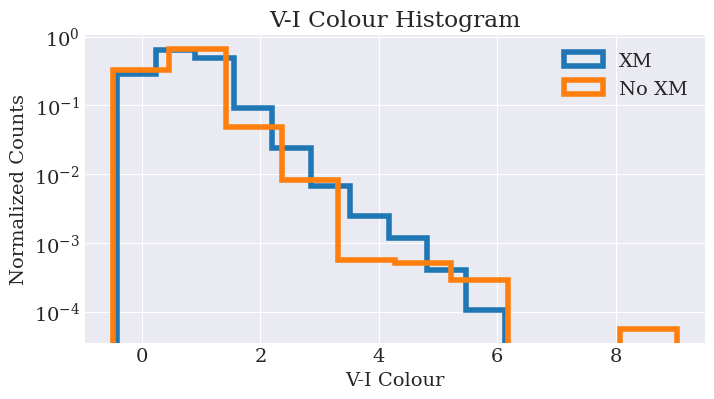

In [30]:
# Magnitude & Colour Histograms
sets = [[hp_xm, hp_noxm],[bv_xm, bv_noxm],[vi_xm, vi_noxm]]
labels = [r"Apparent H$_p$ Magnitude", "B-V Colour", "V-I Colour"]
save_name = ['hp', 'bv', 'vi']

for i in range(len(labels)):
    set_xm = sets[i][0]
    set_noxm = sets[i][1]

    fig, ax = plt.subplots(1,1, figsize=(8, 4))
    ax.hist(set_xm, density=True, log=True, histtype='step', lw=4, label='XM')
    ax.hist(set_noxm, density=True, log=True, histtype='step', lw=4, label='No XM')

    if 'Magnitude' in labels[i]:
        ax.invert_xaxis()

    ax.set_xlabel(labels[i])
    ax.set_ylabel("Normalized Counts")
    ax.set_title(labels[i]+" Histogram")

    plt.legend()
    plt.savefig(fpath+'ida_'+save_name[i], bbox_inches='tight', transparent=True)
    plt.show()

/tmp/ipykernel_62920/2826435628.py:2: RuntimeWarning: divide by zero encountered in log10
  abs_hp_xm = hp_xm + 5.*(np.log10(plx_xm/1e3) + 1.)
/tmp/ipykernel_62920/2826435628.py:2: RuntimeWarning: invalid value encountered in log10
  abs_hp_xm = hp_xm + 5.*(np.log10(plx_xm/1e3) + 1.)
/tmp/ipykernel_62920/2826435628.py:3: RuntimeWarning: divide by zero encountered in log10
  abs_hp_noxm = hp_noxm + 5.*(np.log10(plx_noxm/1e3) + 1.)
/tmp/ipykernel_62920/2826435628.py:3: RuntimeWarning: invalid value encountered in log10
  abs_hp_noxm = hp_noxm + 5.*(np.log10(plx_noxm/1e3) + 1.)


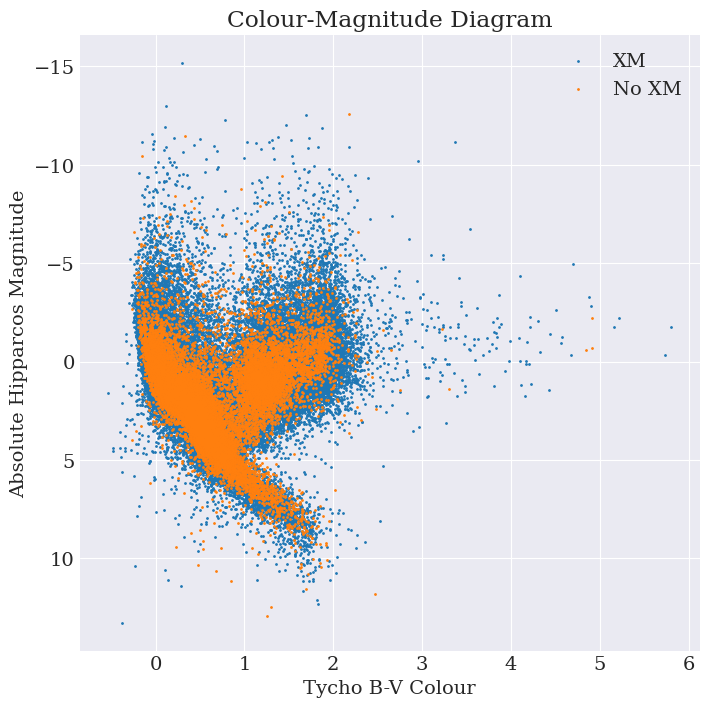

In [35]:
# Colour Magnitude Diagram
abs_hp_xm = hp_xm + 5.*(np.log10(plx_xm/1e3) + 1.)
abs_hp_noxm = hp_noxm + 5.*(np.log10(plx_noxm/1e3) + 1.)

tbv_xm = b_xm - v_xm
tbv_noxm = b_noxm - v_noxm

fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.scatter(tbv_xm, abs_hp_xm, s=1, label='XM')
ax.scatter(tbv_noxm, abs_hp_noxm, s=1, label='No XM')

ax.set_xlabel("Tycho B-V Colour")
ax.set_ylabel("Absolute Hipparcos Magnitude")
ax.set_title("Colour-Magnitude Diagram")
ax.invert_yaxis()

plt.legend()
plt.savefig(fpath+'ida_cmd', bbox_inches='tight', transparent=True)
plt.show()